# TM EI L Baseline

This notebook tests whether subtracting a matched baseline can reduce the dependence of transport-map EI estimates on the intervention range `L`.

The experiment uses known dynamics only. It does not evaluate synergy and does not touch the air-quality pipeline.

## Experiment Logic

For each known dynamics `F`, source samples are drawn from `Uniform([-L/2, L/2]^d)` and the target is generated as `y = F(x) + noise`. We estimate raw `EI_tm = I_tm(phi(x); y)`, then subtract one of several same-`L` baselines:

- `null`: target is independent noise.
- `identity`: target is an identity/projection channel with the same noise.
- `gain_matched`: best linear least-squares channel fitted to the current dynamics signal.
- `variance_matched`: linear projection with output variance matched to the current dynamics signal.
- `shuffled_target`: target marginal is preserved but source-target dependence is broken.
- `analytic_volume`: subtracts `source_dim * log(L)` directly.

A useful baseline should reduce the slope of `EI` against `log(L)` without erasing meaningful differences between known dynamics.

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'exp':
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from exp.tm_ei_l_baseline_support import (
    DEFAULT_BASELINES,
    DEFAULT_DYNAMICS_SPECS,
    plot_raw_and_baseline_ei_by_l,
    plot_best_corrected_ei_by_l,
    plot_baseline_slope_reduction,
    plot_raw_vs_corrected_by_l,
    run_ei_l_baseline_sweep,
    write_experiment_artifacts,
)

OUTPUT_DIR = REPO_ROOT / 'fig' / 'transport_map_mutual_information'
TEST_MODE = os.environ.get('YRD_NOTEBOOK_TEST_MODE', '').strip() == '1'
SEED = 20260429

CONFIG = {
    'l_values': (1.0, 2.0, 4.0) if TEST_MODE else (0.5, 1.0, 2.0, 4.0, 8.0, 12.0, 16.0),
    'dynamics_specs': DEFAULT_DYNAMICS_SPECS[:3] if TEST_MODE else DEFAULT_DYNAMICS_SPECS,
    'baselines': DEFAULT_BASELINES,
    'n_samples': 512 if TEST_MODE else 4096,
    'sample_count_mode': 'fixed_density',
    'reference_l': 4.0,
    'min_n_samples': 128 if TEST_MODE else 512,
    'max_n_samples': None,
    'repeats': 2 if TEST_MODE else 10,
    'base_noise_std': 0.05,
    'noise_modes': ('fixed',) if TEST_MODE else ('fixed', 'scaled_with_l'),
    'seed': SEED,
}
CONFIG

{'l_values': (0.5, 1.0, 2.0, 4.0, 8.0, 12.0, 16.0),
 'dynamics_specs': ({'dynamics': 'identity',
   'source_dim': 1,
   'target_dim': 1,
   'label': 'identity'},
  {'dynamics': 'linear_gain',
   'source_dim': 1,
   'target_dim': 1,
   'gain': 0.5,
   'label': 'gain=0.5'},
  {'dynamics': 'linear_gain',
   'source_dim': 1,
   'target_dim': 1,
   'gain': 2.0,
   'label': 'gain=2.0'},
  {'dynamics': 'product',
   'source_dim': 2,
   'target_dim': 1,
   'label': 'product'},
  {'dynamics': 'tanh',
   'source_dim': 1,
   'target_dim': 1,
   'beta': 1.0,
   'label': 'tanh'}),
 'baselines': ('null',
  'identity',
  'gain_matched',
  'variance_matched',
  'shuffled_target',
  'analytic_volume'),
 'n_samples': 4096,
 'sample_count_mode': 'fixed_density',
 'reference_l': 4.0,
 'min_n_samples': 512,
 'max_n_samples': None,
 'repeats': 10,
 'base_noise_std': 0.05,
 'noise_modes': ('fixed', 'scaled_with_l'),
 'seed': 20260429}

## Run Sweep

The full grid is intentionally moderate but not tiny. Set `YRD_NOTEBOOK_TEST_MODE=1` to run a smoke grid for CI or quick validation.

In [2]:
results = run_ei_l_baseline_sweep(**CONFIG)
runs = results['runs']
baselines = results['baselines']
corrected = results['corrected']
summary = results['summary']

{
    'runs': runs.shape,
    'baselines': baselines.shape,
    'corrected': corrected.shape,
    'summary': summary.shape,
}

{'runs': (700, 13),
 'baselines': (4200, 15),
 'corrected': (4200, 23),
 'summary': (60, 11)}

In [3]:
artifact_paths = write_experiment_artifacts(
    results=results,
    output_dir=OUTPUT_DIR,
    notebook_path='exp/tm_ei_l_baseline.ipynb',
    config={
        **CONFIG,
        'dynamics_specs': [dict(spec) for spec in CONFIG['dynamics_specs']],
        'baselines': list(CONFIG['baselines']),
        'l_values': list(CONFIG['l_values']),
        'noise_modes': list(CONFIG['noise_modes']),
        'sample_count_mode': CONFIG['sample_count_mode'],
        'reference_l': CONFIG['reference_l'],
        'min_n_samples': CONFIG['min_n_samples'],
        'max_n_samples': CONFIG['max_n_samples'],
        'test_mode': TEST_MODE,
    },
)
artifact_paths

{'runs_csv': '/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/tm_ei_l_baseline_runs.csv',
 'baselines_csv': '/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/tm_ei_l_baseline_baselines.csv',
 'corrected_csv': '/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/tm_ei_l_baseline_corrected.csv',
 'summary_csv': '/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/tm_ei_l_baseline_summary.csv',
 'manifest_json': '/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/tm_ei_l_baseline_manifest.json'}

## Slope Summary

`corrected_slope_log_l` is the main diagnostic. Values closer to zero indicate weaker residual `L` dependence after baseline subtraction.

In [4]:
display_columns = [
    'label',
    'noise_mode',
    'baseline',
    'raw_slope_log_l',
    'corrected_slope_log_l',
    'slope_abs_reduction',
    'raw_cv_l',
    'corrected_cv_l',
]
summary[display_columns].sort_values(['noise_mode', 'label', 'corrected_slope_log_l']).head(30)

,label,noise_mode,baseline,raw_slope_log_l,corrected_slope_log_l,slope_abs_reduction,raw_cv_l,corrected_cv_l
17,gain=0.5,fixed,analytic_volume,0.954738,-0.045262,0.909476,0.491271,0.061771
13,gain=0.5,fixed,identity,0.954738,-0.029351,0.925387,0.491271,0.067368
14,gain=0.5,fixed,gain_matched,0.954738,-0.004005,0.950733,0.491271,1.241820
15,gain=0.5,fixed,variance_matched,0.954738,0.001000,0.953738,0.491271,3.086812
16,gain=0.5,fixed,shuffled_target,0.954738,0.954837,-0.000099,0.491271,0.491353
12,gain=0.5,fixed,null,0.954738,0.955022,-0.000284,0.491271,0.491463
29,gain=2.0,fixed,analytic_volume,0.996987,-0.003013,0.993975,0.325631,0.002301
26,gain=2.0,fixed,gain_matched,0.996987,-0.002013,0.994974,0.325631,2.334924
27,gain=2.0,fixed,variance_matched,0.996987,0.002480,0.994508,0.325631,10.074969
25,gain=2.0,fixed,identity,0.996987,0.008943,0.988044,0.325631,0.022970


In [5]:
best_by_case = (
    summary.assign(abs_corrected_slope=summary['corrected_slope_log_l'].abs())
    .sort_values(['noise_mode', 'label', 'abs_corrected_slope'])
    .groupby(['noise_mode', 'label'], as_index=False)
    .first()
)
best_by_case[display_columns + ['abs_corrected_slope']]

,label,noise_mode,baseline,raw_slope_log_l,corrected_slope_log_l,slope_abs_reduction,raw_cv_l,corrected_cv_l,abs_corrected_slope
0,gain=0.5,fixed,variance_matched,0.954738,0.001000,0.953738,0.491271,3.086812,0.001000
1,gain=2.0,fixed,gain_matched,0.996987,-0.002013,0.994974,0.325631,2.334924,0.002013
2,identity,fixed,variance_matched,0.985531,-0.000903,0.984628,0.394932,4.932921,0.000903
3,product,fixed,variance_matched,1.799051,-0.000984,1.798067,0.689836,6.975359,0.000984
4,tanh,fixed,shuffled_target,0.047686,0.047681,0.000006,0.254941,0.254935,0.047681
5,gain=0.5,scaled_with_l,variance_matched,-0.000857,0.000535,0.000322,0.004839,3.218719,0.000535
6,gain=2.0,scaled_with_l,null,0.000367,0.000205,0.000162,0.001102,0.001071,0.000205
7,identity,scaled_with_l,variance_matched,-0.001471,-0.000322,0.001149,0.002105,6.966504,0.000322
8,product,scaled_with_l,variance_matched,0.893283,-0.001617,0.891666,0.583665,3.503278,0.001617
9,tanh,scaled_with_l,gain_matched,-0.418077,0.004553,0.413524,0.452025,2.774873,0.004553


## Figures

Legends are placed outside the axes to avoid covering lines or markers.

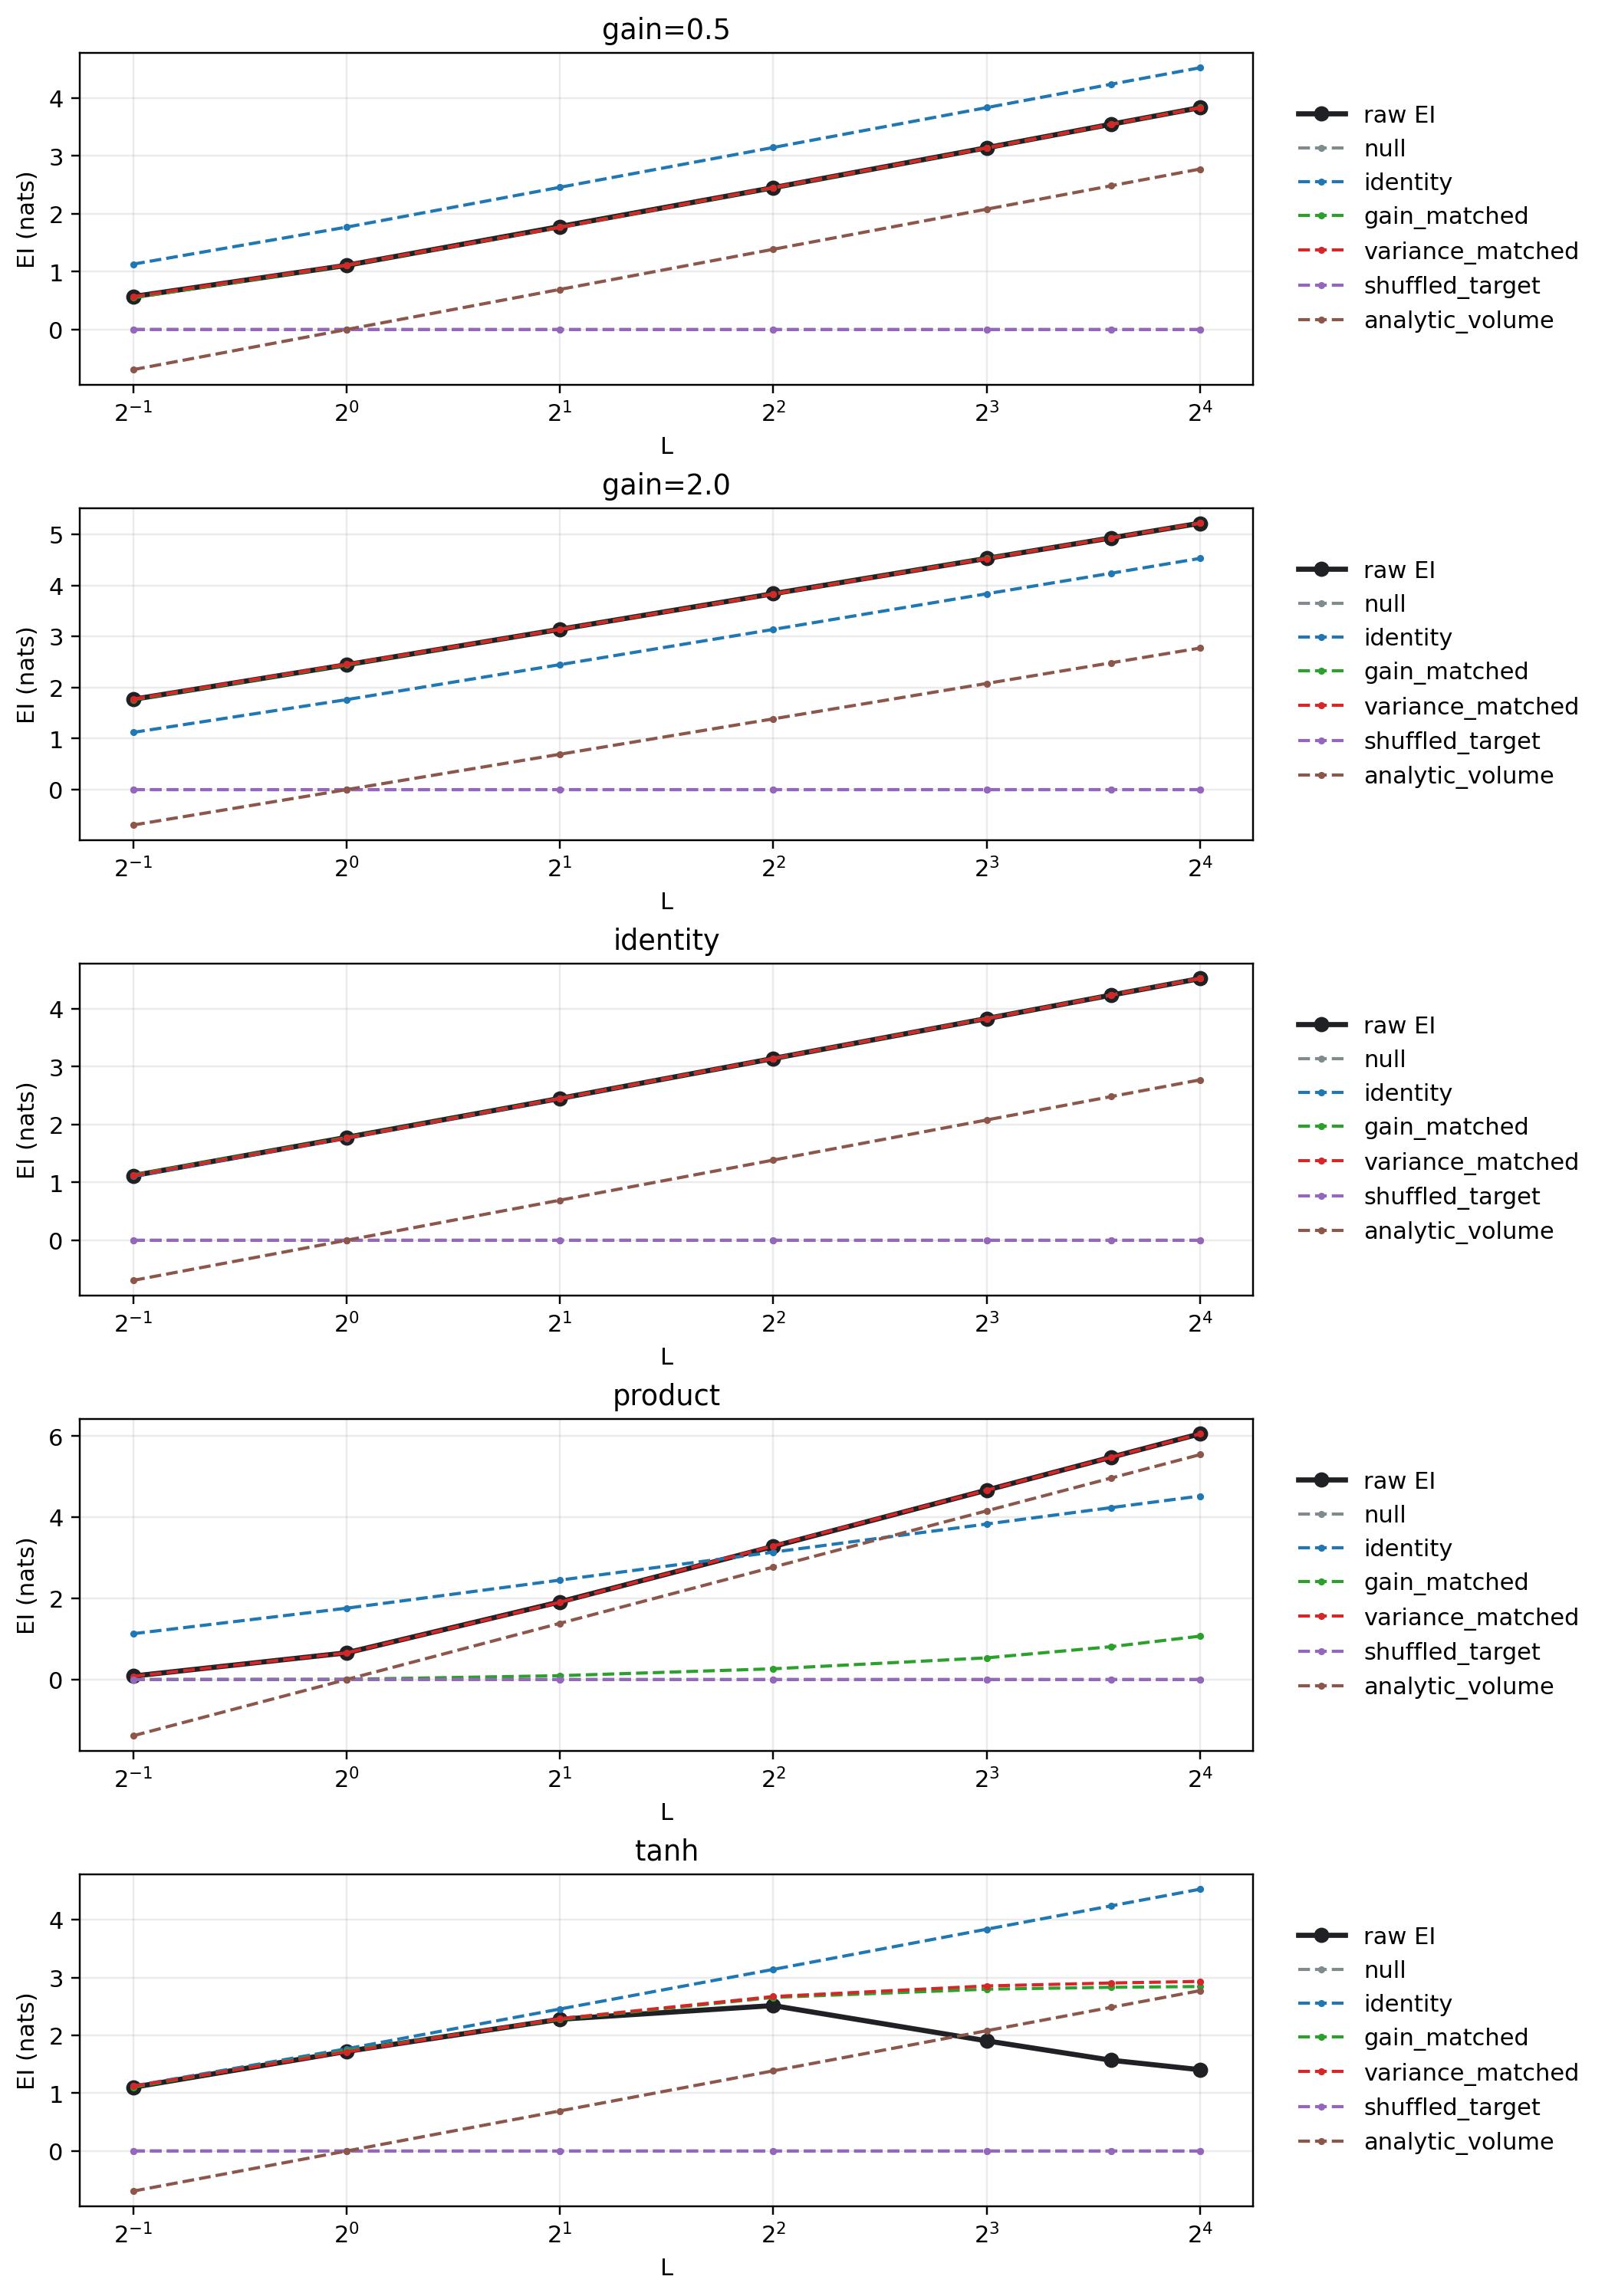

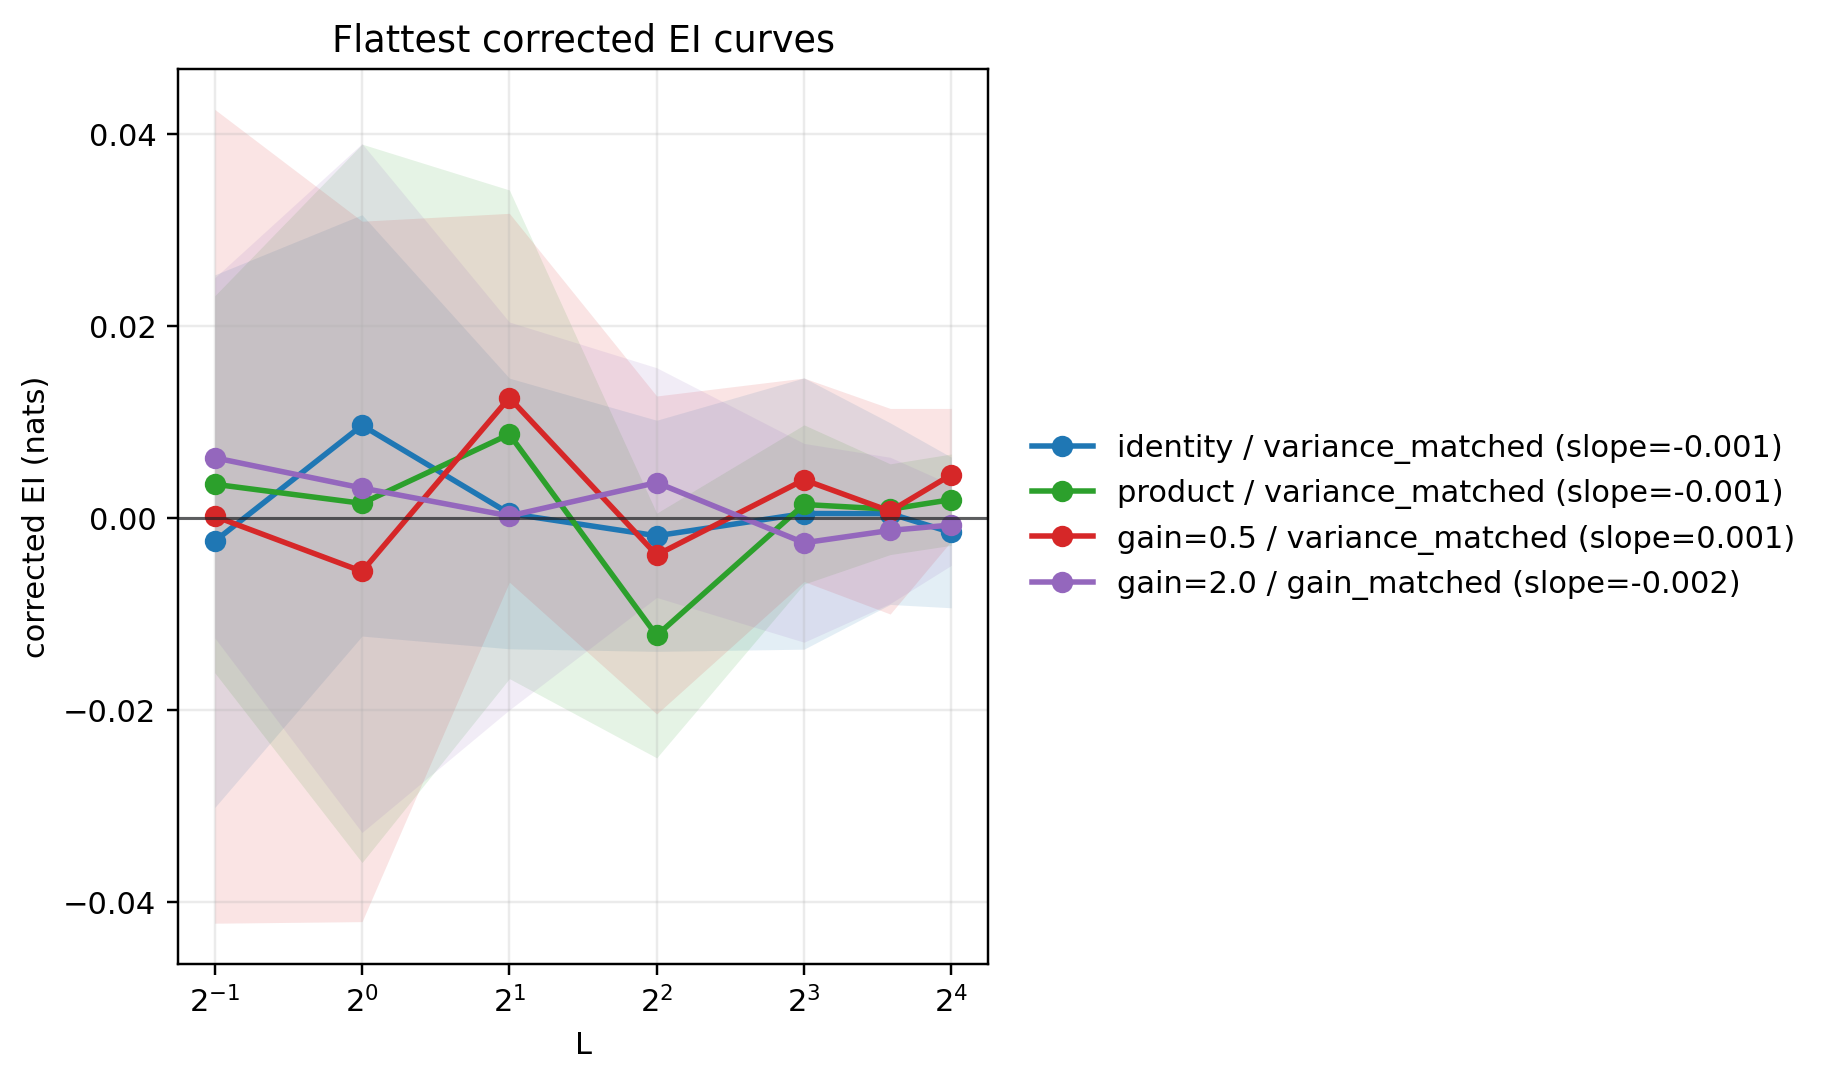

{'raw_and_baseline_curves': ['/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/tm_ei_l_baseline_raw_and_baseline_curves.png',
  '/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/tm_ei_l_baseline_raw_and_baseline_curves.pdf'],
 'best_corrected_curves': ['/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/tm_ei_l_baseline_best_corrected_curves.png',
  '/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/tm_ei_l_baseline_best_corrected_curves.pdf'],
 'raw_vs_corrected': ['/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/tm_ei_l_baseline_raw_vs_corrected.png',
  '/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/tm_ei_l_baseline_raw_vs_corrected.pdf'],
 'slope_reduction': ['/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/tm_ei_l_baseline_slope_reduction.png',
  '/User

In [6]:
raw_baseline_png, raw_baseline_pdf, raw_baseline_table = plot_raw_and_baseline_ei_by_l(
    runs,
    baselines,
    output_dir=OUTPUT_DIR,
    noise_mode='fixed',
)
display(Image(filename=str(raw_baseline_png)))

best_curve_png, best_curve_pdf, best_curve_table = plot_best_corrected_ei_by_l(
    corrected,
    summary,
    output_dir=OUTPUT_DIR,
    noise_mode='fixed',
    max_abs_slope=0.08,
)
display(Image(filename=str(best_curve_png)))
best_curve_table[['label', 'baseline', 'corrected_slope_log_l', 'abs_corrected_slope']]

raw_vs_corrected_figures = plot_raw_vs_corrected_by_l(
    corrected,
    output_dir=OUTPUT_DIR,
    noise_mode='fixed',
    dynamics_labels=tuple(dict.fromkeys(corrected['label'].tolist()))[:3],
)
slope_figures = plot_baseline_slope_reduction(summary, output_dir=OUTPUT_DIR, noise_mode='fixed')
{
    'raw_and_baseline_curves': [str(raw_baseline_png), str(raw_baseline_pdf)],
    'best_corrected_curves': [str(best_curve_png), str(best_curve_pdf)],
    'raw_vs_corrected': [str(path) for path in raw_vs_corrected_figures],
    'slope_reduction': [str(path) for path in slope_figures],
}

## Interpretation Checklist

- `null` should mainly reveal estimator bias; it is not expected to remove the physical `L` effect.
- `identity` should work best for identity-like linear channels.
- `gain_matched` is the strongest simulated correction; if it works, the corrected quantity should be read as excess EI beyond the best linear channel.
- `variance_matched` may help product dynamics because the output scale grows quickly with `L`, but it can also over-correct genuine mechanism strength.
- `analytic_volume` is the cleanest theoretical control but only removes a simple `d log L` term.